# Bibliotecas

In [ ]:
import os
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm, jarque_bera, shapiro # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

##Funções

In [42]:
!rm -rf /content/Mercado-Artificial-Fiis
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git

import sys

if "msm" in sys.modules:
    del sys.modules["msm"]


caminho = "/content/Mercado-Artificial-Fiis/notebooks/funcoes"
if caminho not in sys.path:
    sys.path.append(caminho)


import msm

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 68 (delta 28), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 42.37 KiB | 8.47 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [43]:
dir(msm)

['Callable',
 'Dict',
 'Iterable',
 'List',
 'Optional',
 'Pool',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'acf',
 'calcular_erros_calibracao',
 'calcular_momentos_uma_serie',
 'calcular_power_law',
 'construir_M_momentos_bootstrap',
 'curve_fit',
 'dataclass',
 'dt',
 'extrair_powerlaw_bootstrap',
 'field',
 'gaussian_kde',
 'itertools',
 'jarque_bera',
 'kurtosis',
 'matriz_pesos_W',
 'matriz_variancia_covariancia_dos_momentos',
 'moving_block_bootstrap',
 'norm',
 'np',
 'os',
 'pd',
 'plot_acf',
 'plt',
 'qqplot',
 'random',
 'resumo_distribuicao_com_kde',
 'shapiro',
 'skew',
 'sm',
 'sns',
 'tabela_bootstrap_unica',
 'traceback',
 'truncnorm',
 'warnings',
 'yf']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.stats import gaussian_kde
except ImportError:
    gaussian_kde = None


def plot_histograma(
    dados,
    titulo="Título",
    xlabel="Eixo x",
    ylabel="Densidade",
    grade=True,
    bins=30,
    kde=True,
    mostrar_mediana=True,
    mostrar_ic=True,
    alpha=0.55,
    figsize=(8, 4.8),
    xlim=None
):
    # transforma em array numpy 1D
    dados = np.asarray(dados, dtype=float).ravel()

    # mantém apenas valores finitos
    dados = dados[np.isfinite(dados)]

    # verifica se sobrou dado
    if len(dados) == 0:
        raise ValueError("Não há dados numéricos válidos para plotar.")

    # estatísticas
    med = np.median(dados)
    ci_low = np.percentile(dados, 2.5)
    ci_high = np.percentile(dados, 97.5)

    # figura
    plt.figure(figsize=figsize)

    # histograma
    plt.hist(
        dados,
        bins=bins,
        density=True,
        alpha=alpha,
        edgecolor="black"
    )

    # KDE opcional
    if kde and gaussian_kde is not None and len(dados) > 1:
        xs = np.linspace(np.min(dados), np.max(dados), 300)
        ys = gaussian_kde(dados)(xs)
        plt.plot(xs, ys, linewidth=2, label="Densidade (KDE)")

    # linhas verticais
    if mostrar_mediana:
        plt.axvline(
            med,
            linestyle="--",
            linewidth=2,
            label=f"Mediana = {med:.3f}"
        )

    if mostrar_ic:
        plt.axvline(
            ci_low,
            linestyle=":",
            linewidth=2,
            label=f"IC inf = {ci_low:.3f}"
        )
        plt.axvline(
            ci_high,
            linestyle=":",
            linewidth=2,
            label=f"IC sup = {ci_high:.3f}"
        )

    # títulos e eixos
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # limite do eixo x
    if xlim is not None:
        plt.xlim(*xlim)

    # grade
    if grade:
        plt.grid(True, alpha=0.25)

    plt.legend()
    plt.tight_layout()
    plt.show()

# Benchmark Empírico

## IFIX

**Dados Iniciais do IFIX**

In [ ]:
url = "https://docs.google.com/spreadsheets/d/1bBVbP7GH3JPcRPPn0qydQJ6H16I3yDbz/export?format=csv"

df = pd.read_csv(url, index_col="Date", parse_dates=True, dayfirst=True)
df.index = pd.to_datetime(df.index, format='%Y-%m-%d')
df["Close"] = df["Close"].astype(str).str.replace(".", "")
df["Close"] = df["Close"].astype(str).str.replace(",", ".").astype(float)
df = df.sort_index(ascending=True)
df_ifix = df.rename(columns={'Close': 'IFIX'})
#df_ifix = df_ifix[:-3]
df_ifix=df_ifix[-1008:]

retorno_diario_bench = np.log(df_ifix).diff().dropna()

# Calcula momentos do benchmark
bench_mean = np.mean(retorno_diario_bench).item()
bench_std = np.var(retorno_diario_bench).item()
bench_skew = skew(retorno_diario_bench, axis = 0)[0]
bench_kurt = kurtosis(retorno_diario_bench, fisher=True, axis = 0)[0]
momentos_bench = np.array([bench_mean, bench_std, bench_skew, bench_kurt])

print(momentos_bench)

[4.50583238e-05 1.40863628e-05 2.63747218e-01 6.71320518e+00]


**Dados até final de 2025**

In [ ]:
url = "https://docs.google.com/spreadsheets/d/1Ijr7MuSuCHXgDLv-xhEktMWeyEQsmjd6/export?format=csv"

df = pd.read_csv(url, index_col="Date", parse_dates=True, dayfirst=True)
df.index = pd.to_datetime(df.index, format='%Y-%m-%d')
df["Close"] = df["Close"].astype(str).str.replace(".", "")
df["Close"] = df["Close"].astype(str).str.replace(",", ".").astype(float)
df = df.sort_index(ascending=True)
df_ifix = df.rename(columns={'Close': 'IFIX'})
#df_ifix = df_ifix[:-3]
df_ifix=df_ifix[-1250:]

retorno_diario_bench = np.log(df_ifix).diff().dropna()

# Calcula momentos do benchmark
bench_mean = np.mean(retorno_diario_bench).item()
bench_std = np.var(retorno_diario_bench).item()
bench_skew = skew(retorno_diario_bench, axis = 0)[0]
bench_kurt = kurtosis(retorno_diario_bench, fisher=True, axis = 0)[0]
momentos_bench = np.array([bench_mean, bench_std, bench_skew, bench_kurt])

print(momentos_bench)

[2.23696273e-04 1.32447214e-05 1.90985928e-01 6.22537708e+00]


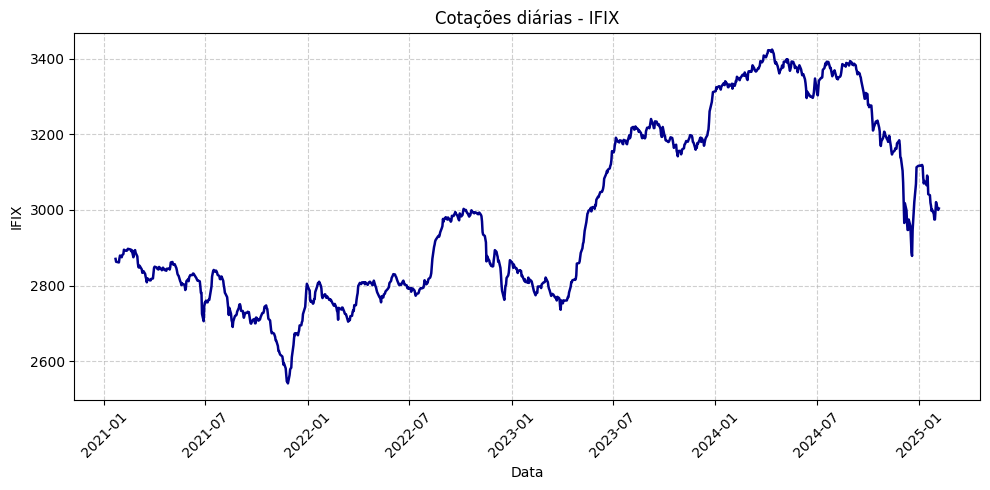

In [ ]:
# Plot do IFIX
plt.figure(figsize=(10, 5))
plt.plot(df_ifix.index, df_ifix["IFIX"], color="darkblue", linewidth=1.8)
plt.xlabel("Data")
plt.ylabel("IFIX")
plt.title("Cotações diárias - IFIX")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **MBB- 60 dias**

In [ ]:
serie_empirica = retorno_diario_bench.dropna()

In [ ]:
# Gera 1000 amostras bootstrap
bootstraps = msm.moving_block_bootstrap(serie_empirica, block_size=5, sample_size=60, n_replications=1000, random_state=0)

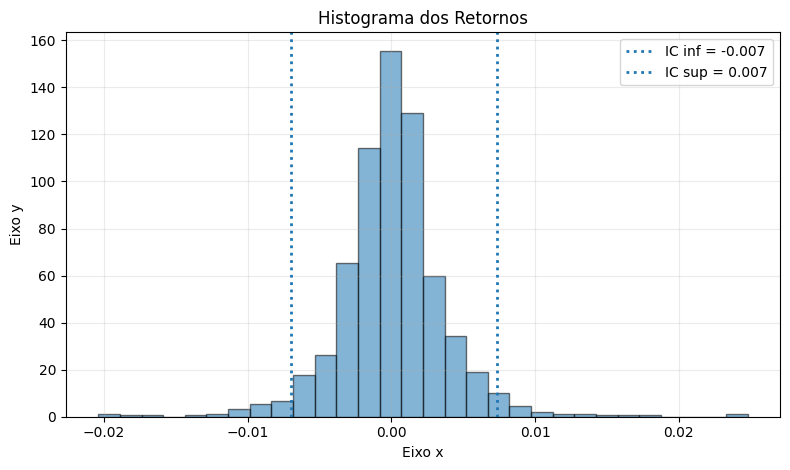

In [ ]:
plot_histograma(serie_empirica,
                titulo="Histograma dos Retornos",
                xlabel="Eixo x",
                ylabel="Eixo y",
                bins=30,
                mostrar_mediana = False,
                kde=False,
                grade = True)

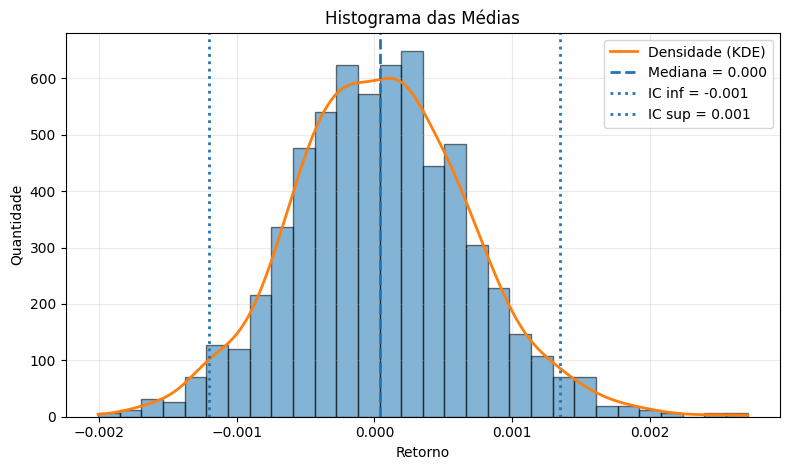

In [ ]:
medias = np.mean(bootstraps, axis=1)
plot_histograma(medias, titulo="Histograma das Médias", xlabel="Retorno", ylabel="Quantidade", bins=30, grade = True)

In [44]:
momentos_bootstrap_60 = msm.construir_M_momentos_bootstrap(bootstraps)
momentos_bootstrap_60

,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.000118,0.000012,0.213727,4.515868,0.093849,-0.122388,-0.132560,-0.076454,0.273853,-0.061368
1,0.000119,0.000025,1.360185,10.886374,-0.082424,-0.089303,-0.015188,-0.090675,0.002511,0.193771
2,0.000625,0.000009,-0.042527,3.723290,-0.007000,-0.008742,-0.056362,0.000095,0.010856,0.244433
3,-0.000150,0.000005,0.302188,3.525203,-0.006252,-0.007793,-0.098288,-0.166206,0.077692,-0.093040
4,0.000295,0.000013,0.425409,4.184820,-0.152329,0.005074,-0.026395,-0.221523,0.355770,0.199653
...,...,...,...,...,...,...,...,...,...,...
995,-0.000388,0.000011,-0.920069,7.438234,-0.056430,-0.062752,-0.152600,0.038665,-0.076236,0.238365
996,0.000841,0.000017,0.741133,4.659425,-0.071633,0.018509,-0.070051,-0.031997,0.148357,-0.027875
997,-0.000745,0.000009,-0.055975,3.016133,0.007275,-0.248822,-0.190293,0.056900,0.194717,0.086611
998,0.000343,0.000008,0.142073,4.202264,-0.097155,-0.079164,-0.007455,0.001047,0.129140,0.325146


In [45]:
df_referencia_empirica_60 = msm.tabela_bootstrap_unica(
    bootstraps,
    acf_raw_lags=[5,10,15,20],
    acf_sq_lags=[1,2],
    acf_abs_lags=[1],
    alpha=0.05
)
df_referencia_empirica_60 = df_referencia_empirica_60.iloc[0:10]
df_referencia_empirica_60

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000052,0.000646,-0.001203,0.001351
1,Variancia(ddof=1),0.000014,0.000008,0.000005,0.000037
2,Assimetria(skew),0.013964,0.913351,-1.784080,2.078316
3,Curtose(fisher=False),5.735955,2.810985,2.787951,12.936896
4,retornos_ACF(lag=5),-0.029352,0.119243,-0.274610,0.191849
5,retornos_ACF(lag=10),-0.021469,0.113322,-0.251494,0.210195
6,retornos_ACF(lag=15),-0.017443,0.111847,-0.234302,0.212489
7,retornos_ACF(lag=20),-0.023073,0.103335,-0.240387,0.167221
8,retornos2_ACF(lag=1),0.204947,0.209008,-0.092942,0.671057
9,retornos2_ACF(lag=2),0.080851,0.151514,-0.155613,0.396847


## **MBB - 500 dias**

In [46]:
bootstraps_500 = msm.moving_block_bootstrap(serie_empirica, block_size=10, sample_size=500, n_replications=1000, random_state=0)

In [47]:
momentos_bootstrap_500 = msm.construir_M_momentos_bootstrap(bootstraps_500)
momentos_bootstrap_500

,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.000141,0.000011,0.666245,9.369070,0.100422,0.040643,0.009899,-0.006169,0.151660,0.214680
1,0.000399,0.000012,1.008534,9.101307,0.102057,-0.066555,-0.050478,-0.124395,0.379003,0.207572
2,0.000045,0.000010,-0.076848,6.461567,0.019966,-0.073364,-0.030344,0.025610,0.162999,0.036368
3,-0.000124,0.000020,0.751546,9.421992,0.117835,-0.053933,-0.026230,0.061686,0.454738,0.242761
4,-0.000220,0.000016,0.615142,10.042503,0.108040,0.139802,-0.033636,-0.009115,0.516478,0.201094
...,...,...,...,...,...,...,...,...,...,...
995,-0.000264,0.000014,-0.640608,6.170653,-0.020584,-0.031439,-0.044978,0.040167,0.338306,0.157199
996,-0.000085,0.000011,-0.603628,8.816381,0.078251,0.052669,-0.145757,0.068977,0.555057,0.408623
997,0.000241,0.000011,-0.760707,9.645327,0.125860,-0.037561,-0.051501,0.010615,0.115966,0.201113
998,0.000147,0.000011,-0.079759,8.478551,0.122388,0.075095,-0.010118,0.060319,0.258597,0.003081


In [48]:
df_500 = msm.tabela_bootstrap_unica(
    bootstraps_500,
    acf_raw_lags=[5,10,15,20],
    acf_sq_lags=[1,2],
    acf_abs_lags=[1],
    alpha=0.05
)
df_500 = df_500.iloc[0:10]
df_500

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000031,0.000243,-0.000454,0.000512
1,Variancia(ddof=1),0.000014,0.000003,0.000009,0.000021
2,Assimetria(skew),0.154954,0.667821,-0.854268,1.531713
3,Curtose(fisher=False),8.651156,2.518067,4.243442,13.694373
4,retornos_ACF(lag=5),0.070739,0.062490,-0.051118,0.190350
5,retornos_ACF(lag=10),-0.006074,0.047246,-0.093547,0.088684
6,retornos_ACF(lag=15),-0.005999,0.046735,-0.101424,0.085490
7,retornos_ACF(lag=20),-0.002012,0.047080,-0.095975,0.088147
8,retornos2_ACF(lag=1),0.368042,0.178912,0.086816,0.633222
9,retornos2_ACF(lag=2),0.244271,0.118946,0.008504,0.429600


### Power Law

In [49]:
df_power = msm.extrair_powerlaw_bootstrap(
    bootstraps_500=bootstraps_500,
    historico_inicial=None,  # coloque None se não quiser concatenar
    max_lag=40,
    b_max=3.0
)

print("Réplicas válidas:", len(df_power), "de", len(bootstraps_500))
df_power.head()

Réplicas válidas: 978 de 1000


,replica,b,r2
0,0,1.036155,0.625335
1,1,1.433554,0.628963
2,2,1.585749,0.412457
3,3,1.010872,0.614598
4,4,1.011542,0.719287


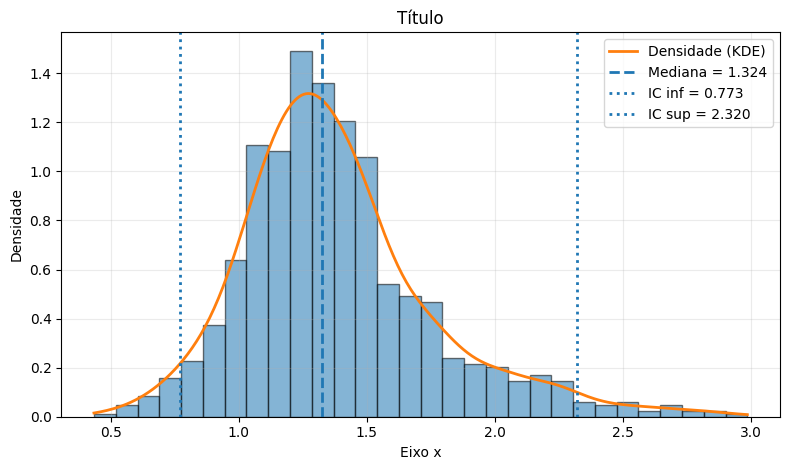

In [50]:
plot_histograma(df_power['b'])

In [51]:
def resumo_serie_df(serie, nome="Série", alpha=0.05):
    """
    Cria um DataFrame com média, desvio padrão, IC_inf e IC_sup de uma série.

    Parâmetros
    ----------
    serie : array-like
        Série de dados.
    nome : str
        Nome da série no DataFrame.
    alpha : float
        Nível de significância. alpha=0.05 gera IC de 95%.

    Retorna
    -------
    pd.DataFrame
    """
    x = np.asarray(serie, dtype=float).ravel()
    x = x[np.isfinite(x)]

    if x.size == 0:
        raise ValueError("A série não possui valores numéricos válidos.")

    media = np.mean(x)
    dp = np.std(x, ddof=1) if x.size > 1 else np.nan
    ic_inf = np.percentile(x, 100 * (alpha / 2))
    ic_sup = np.percentile(x, 100 * (1 - alpha / 2))

    return pd.DataFrame([{
        "Série": nome,
        "Média": media,
        "Desvio padrão": dp,
        "IC_inf": ic_inf,
        "IC_sup": ic_sup
    }])

In [52]:
resumo_serie_df(df_power['b'], nome= 'coeficiente b')

,Série,Média,Desvio padrão,IC_inf,IC_sup
0,coeficiente b,1.383007,0.376349,0.77268,2.319563


### Gaussianidade

In [53]:
from scipy.stats import kurtosis
import numpy as np

gaussian_boot = []
escalas = [1, 5, 21]

for j in range(1000):  # 1000 séries bootstrap
    ret = np.array(bootstraps_500[j])
    curtoses = []

    for lag in escalas:
        n_blocos = len(ret) // lag
        agregados = np.array([
            np.sum(ret[i*lag:(i+1)*lag]) for i in range(n_blocos)
        ])
        k = kurtosis(agregados, bias=True, fisher=False)
        curtoses.append(k)

    # Curtose decrescente => evidência de gaussianidade agregacional
    is_gaussian = (curtoses[0] > curtoses[1]) and (curtoses[1] >= curtoses[2])
    gaussian_boot.append(is_gaussian)

# Proporção de séries com comportamento gaussianamente agregacional
prop_gaussian = np.mean(gaussian_boot)
print(f"✅ Proporção de gaussianidade agregacional no bootstrap: {prop_gaussian:.2%}")




✅ Proporção de gaussianidade agregacional no bootstrap: 71.20%


### Gaussianidade Condicional

In [55]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.5 MB/s eta 0:00:00


In [56]:
from arch import arch_model

escalas = [1, 5, 21]
gaussian_boot_garch = []

for j in range(1000):  # para cada série bootstrap

    # 1. Série bootstrap
    ret = np.array(bootstraps_500[j])

    # 2. Ajuste do modelo GARCH(1,1)
    garch_model = arch_model(100 * ret, vol='GARCH', p=1, q=1, dist='gaussian')
    garch_fit   = garch_model.fit(update_freq=0, disp='off')

    # 3. Resíduos padronizados
    std_resid = np.array(garch_fit.resid / garch_fit.conditional_volatility)

    # 4. Curtoses agregadas
    curtoses = []
    for lag in escalas:
        n_blocos = len(std_resid) // lag

        agregados = np.array([
            np.sum(std_resid[i*lag:(i+1)*lag])
            for i in range(n_blocos)
        ])

        k = kurtosis(agregados, bias=True, fisher=False)
        curtoses.append(k)

    # 5. Curtose estritamente decrescente?
    is_dec = (curtoses[0] > curtoses[1]) and (curtoses[1] > curtoses[2])

    # 6. Armazena o resultado
    gaussian_boot_garch.append(is_dec)

# Proporção final de curtose decrescente
prop_gaussian_boot_garch = np.mean(gaussian_boot_garch)

print(f"Proporção de curtose decrescente nos resíduos GARCH (bootstrap): {prop_gaussian_boot_garch:.2%}")


Proporção de curtose decrescente nos resíduos GARCH (bootstrap): 80.30%
